# dvar_F/U correlation exploration

Focus: abs dvar_F, abs dvar_U, and their sum vs log(MFPT WT / mut), with branch/angle views.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

from common.consts import res_colors, groupByResidue
from paper.style_utils import set_paper_style
from common.utils import collect_df
from common.hlda_utils import load_lambda_grid
set_paper_style()
from common.plot_utils import scatter_with_labels

%config InlineBackend.figure_format = 'retina'


In [2]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap="rocket_r"):
    P = df.pivot(index="tF", columns="tU", values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading="flat"
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f"{val:.2f}", ha="center", va="center", fontsize=6)

    ax.set_xlabel("tU")
    ax.set_ylabel("tF")
    ax.set_title(title, fontsize=9)
    return im


In [3]:
data_dir = repo_root / "data"
mfpt_default_pkl = data_dir / "mfpt-pace=25000-new-ref.pkl"
lambda_cache = data_dir / "hlda_lambda_grid.pkl"


with open(mfpt_default_pkl, "rb") as f:
    mfpt_all = pickle.load(f)

mfpt_thresholds = sorted({float(k) for v in mfpt_all.values() for k in v.keys()})



lambda_grid = load_lambda_grid(cache_path=lambda_cache, force=False)

skip_short = set()
unique_tf = sorted(lambda_grid['tF'].unique())
unique_tu = sorted(lambda_grid['tU'].unique())


In [4]:
import numpy as np

# Cache collect_df results once for all thresholds and (tF, tU)
df_cache = {}
for thr in mfpt_thresholds:
    for tF in unique_tf:
        for tU in unique_tu:
            sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
            if sub_lam.empty:
                continue
            df_thr = collect_df(
                mfpt_all,
                mfpt_threshold=float(thr),
                tF=float(tF),
                tU=float(tU),
                lambda_df=sub_lam,
                skip_short=skip_short,
                quiet=True,
            )
            wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
            
            # Existing Metrics
            df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])
            df_thr['mfpt_ratio'] = wt_mfpt / df_thr['mfpt']
            df_thr['abs_dvar_sum'] = df_thr['abs_dvar_F'] + df_thr['abs_dvar_U']
            df_thr['rel_dvar_sum'] = df_thr['rel_dvar_F'] + df_thr['rel_dvar_U']
            
            # --- NEW: Polar Coordinates ---
            # Define your X and Y columns based on the plot
            x_val = df_thr['abs_dvar_F']
            y_val = df_thr['log_mfpt_ratio']
            
            # Calculate Radius (magnitude of change) and Theta (direction of change)
            df_thr['radial_r'] = np.sqrt(x_val**2 + y_val**2)
            df_thr['radial_theta'] = np.arctan2(y_val, x_val)
            # ------------------------------

            df_cache[(float(thr), float(tF), float(tU))] = df_thr

In [5]:
def best_rows_for_prop(prop):
    best_rows = []
    for thr in mfpt_thresholds:
        rows = []
        for tF in unique_tf:
            for tU in unique_tu:
                df_thr = df_cache.get((float(thr), float(tF), float(tU)))
                if df_thr is None:
                    continue
                sub = df_thr.dropna(subset=[prop, 'log_mfpt_ratio']).copy()
                if len(sub) < 2:
                    continue
                rho = sub[prop].corr(sub['log_mfpt_ratio'], method='spearman')
                pear, _ = pearsonr(sub[prop], sub['log_mfpt_ratio'])
                rows.append({
                    'tF': float(tF),
                    'tU': float(tU),
                    'rho': abs(rho) if pd.notna(rho) else np.nan,
                    'pear': abs(pear) if pd.notna(pear) else np.nan,
                })
        if not rows:
            continue
        df = pd.DataFrame(rows).dropna(subset=['rho', 'pear'])
        if df.empty:
            continue
        df['combo'] = 0.5 * (df['rho'] + df['pear'])
        best = df.loc[df['combo'].idxmax()]
        best_rows.append({
            'thr': float(thr),
            'tF': best['tF'],
            'tU': best['tU'],
            'rho': best['rho'],
            'pear': best['pear'],
            'combo': best['combo'],
        })
    return best_rows


In [6]:
props = [
    ('abs_dvar_F', 'abs dvar F'),
    # ('abs_dvar_U', 'abs dvar U'),
    # ('abs_dvar_sum', 'abs dvar F+U'),
    # ('rel_dvar_F', 'rel dvar F (sum)'),
    # ('rel_dvar_U', 'rel dvar U (sum)'),
    # ('rel_dvar_sum', 'rel dvar F+U (sum)'),
]


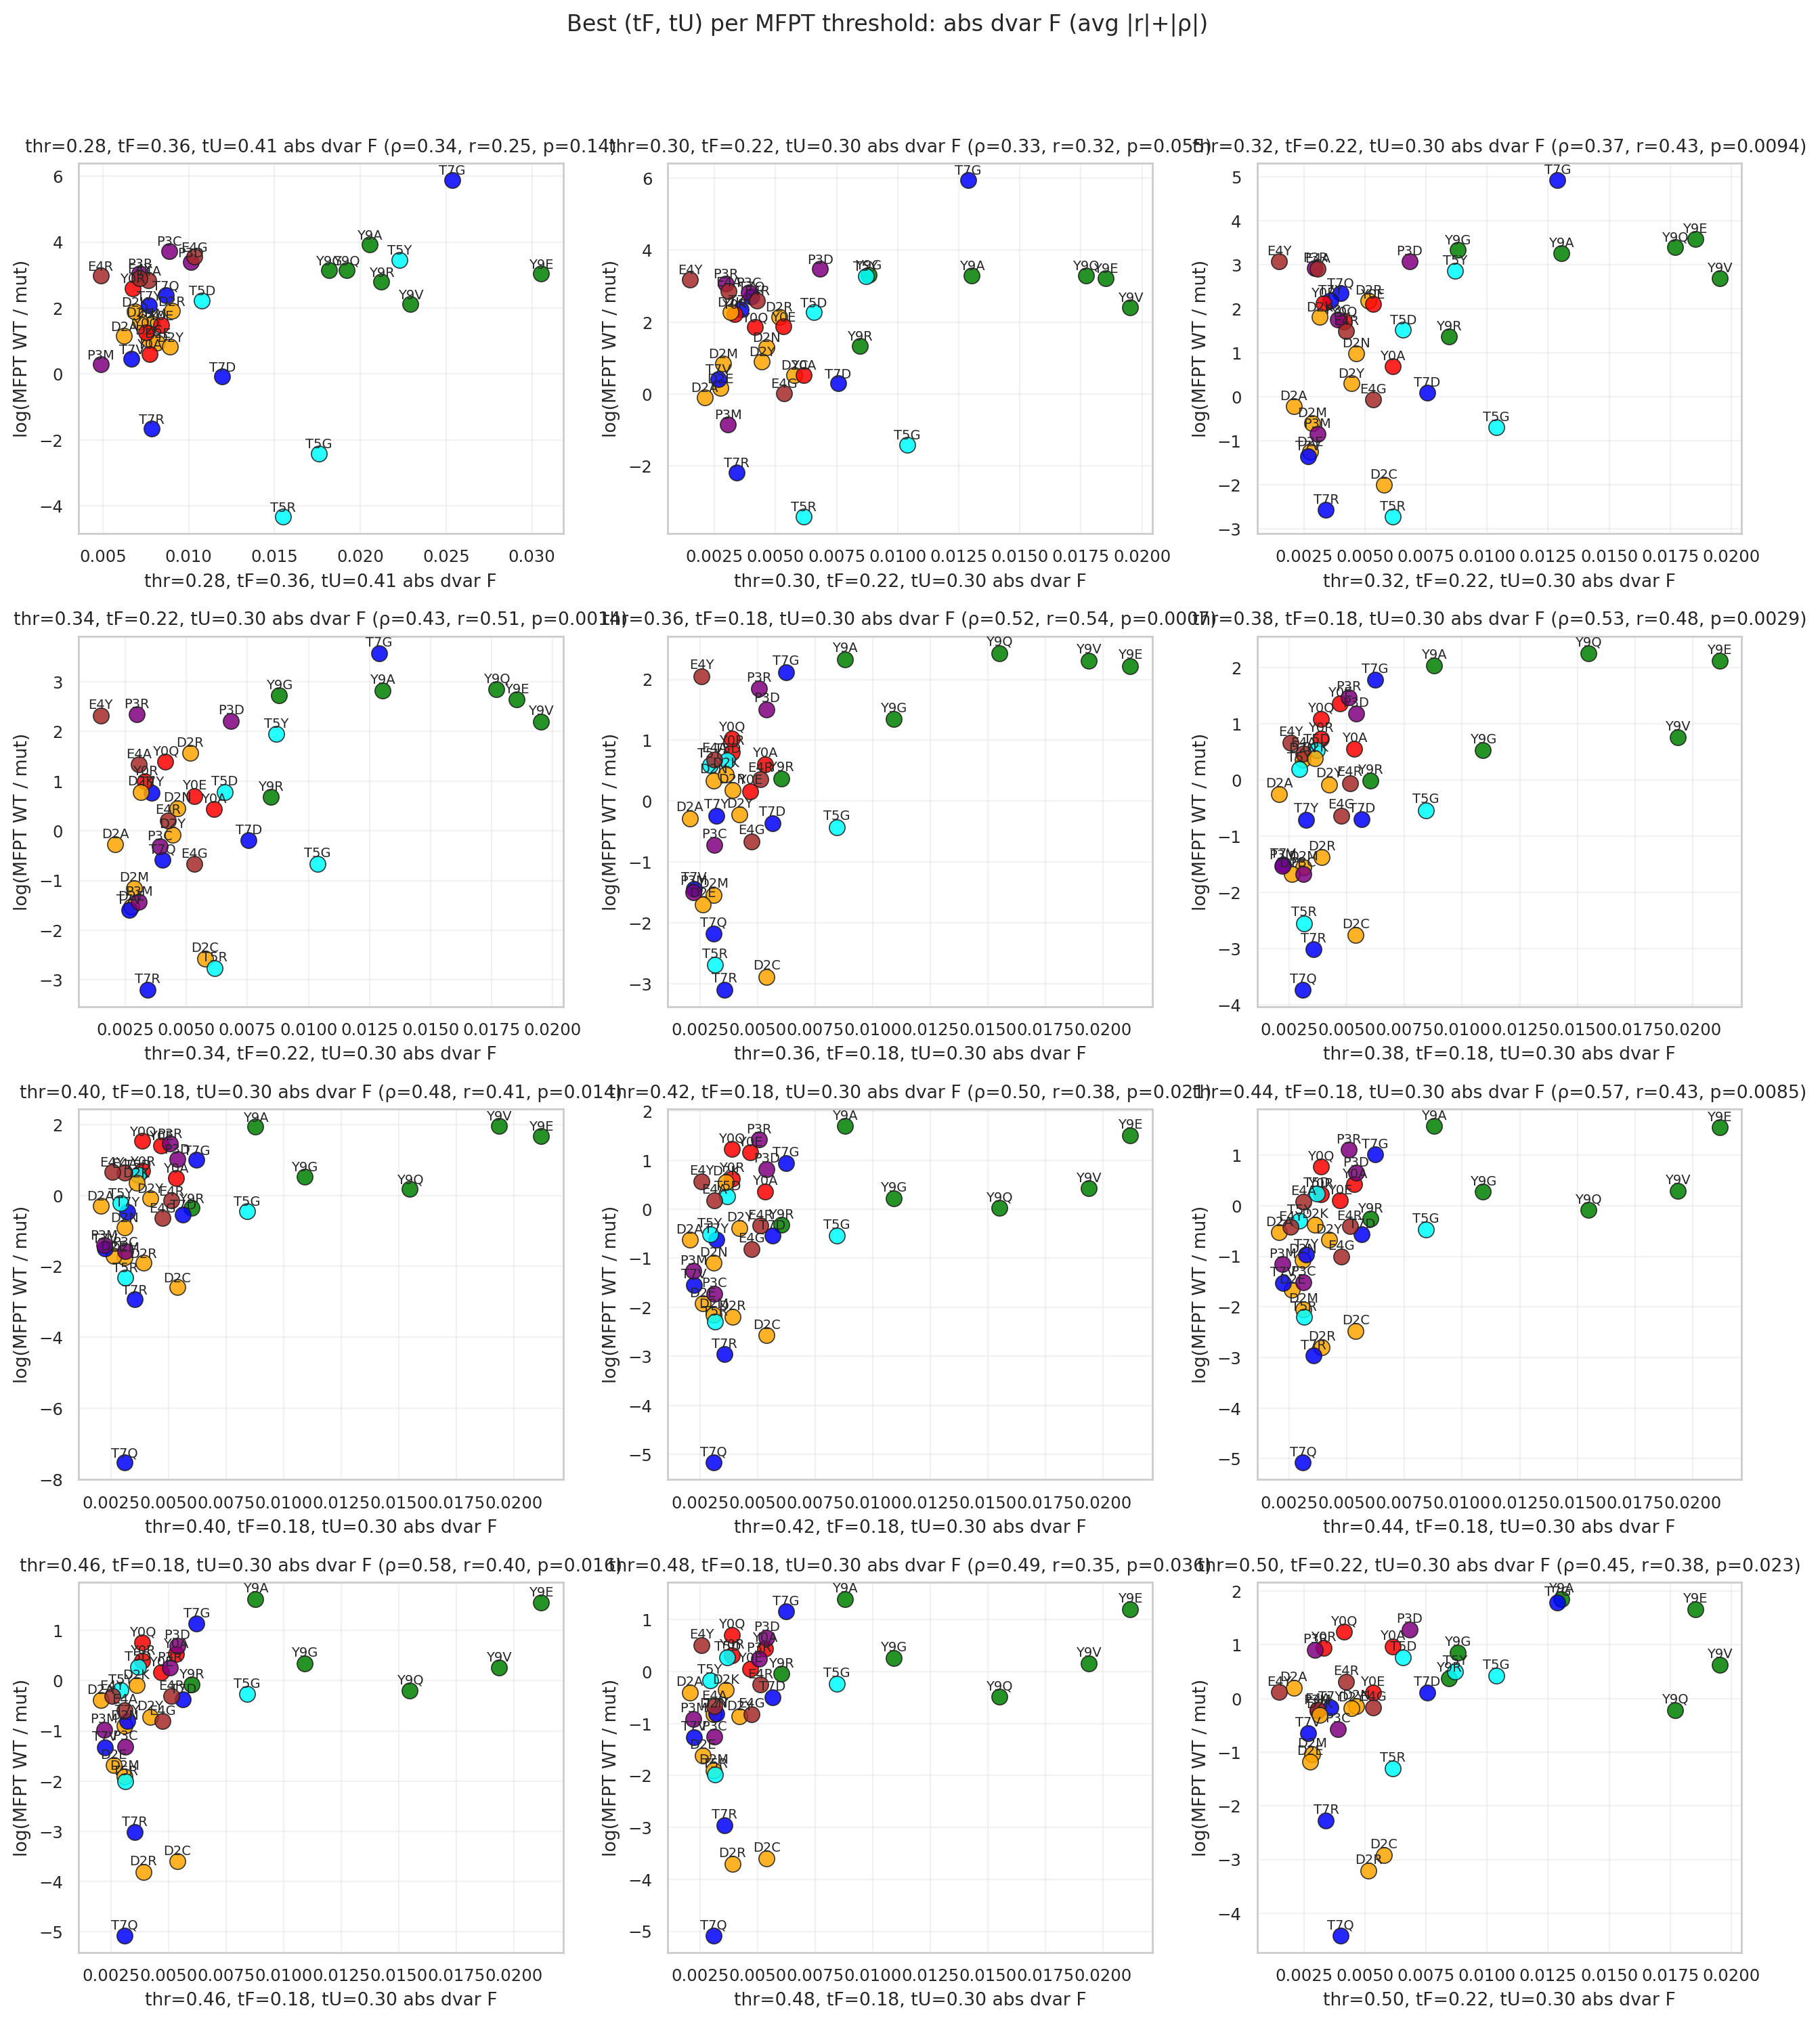

In [7]:
# Best (tF, tU) scatter per threshold
def scatter_basic_radial(df, prop, label, ax):
    sub = df.dropna(subset=[prop, 'log_mfpt_ratio', 'residue_idx']).copy()
    if sub.empty:
        ax.axis('off')
        return

    x = sub[prop].values
    y = sub['log_mfpt_ratio'].values

    # radial magnitude in (x, y) plane
    sub['r'] = np.sqrt(x**2 + y**2)
    sub['abs_y'] = np.abs(y)

    sub['short'] = sub.index.astype(str)

    scatter_with_labels(
        ax,
        sub,
        'r',
        'abs_y',
        label_col='short',
        color_col='residue_idx',
        colors=res_colors,
    )

    rho = sub['r'].corr(sub['abs_y'], method='spearman')
    pear, p = pearsonr(sub['r'], sub['abs_y'])

    ax.set_title(f"{label} (radial) (ρ={rho:.2f}, r={pear:.2f}, p={p:.2g})")
    ax.set_xlabel(r"$\sqrt{x^2 + y^2}$")
    ax.set_ylabel(r"$|\log(\mathrm{MFPT}_{WT}/\mathrm{mut})|$")
    ax.grid(True, alpha=0.25)
    
def scatter_basic(df, prop, label, ax):
    sub = df.dropna(subset=[prop, 'log_mfpt_ratio', 'residue_idx']).copy()
    if sub.empty:
        ax.axis('off')
        return

    sub['short'] = sub.index.astype(str)
    scatter_with_labels(
        ax,
        sub,
        prop,
        'log_mfpt_ratio',
        label_col='short',
        color_col='residue_idx',
        colors=res_colors,
    )

    rho = sub[prop].corr(sub['log_mfpt_ratio'], method='spearman')
    pear, p = pearsonr(sub[prop], sub['log_mfpt_ratio'])
    ax.set_title(f"{label} (ρ={rho:.2f}, r={pear:.2f}, p={p:.2g})")
    ax.set_xlabel(label)
    ax.set_ylabel('log(MFPT WT / mut)')
    ax.grid(True, alpha=0.25)


for prop, label in props:
    best_rows = best_rows_for_prop(prop)

    ncols = min(3, len(best_rows) if best_rows else 1)
    nrows = int(np.ceil(len(best_rows) / ncols)) if best_rows else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)

    for ax, b in zip(axes.ravel(), best_rows):
        tF = float(b['tF'])
        tU = float(b['tU'])
        thr = float(b['thr'])
        df_thr = df_cache.get((float(thr), float(tF), float(tU)))
        if df_thr is None:
            ax.axis('off')
            continue
        scatter_basic(df_thr, prop, f"thr={thr:.2f}, tF={tF:.2f}, tU={tU:.2f} {label}", ax)

    for ax in axes.ravel()[len(best_rows):]:
        ax.axis('off')

    fig.suptitle(f"Best (tF, tU) per MFPT threshold: {label} (avg |r|+|ρ|)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


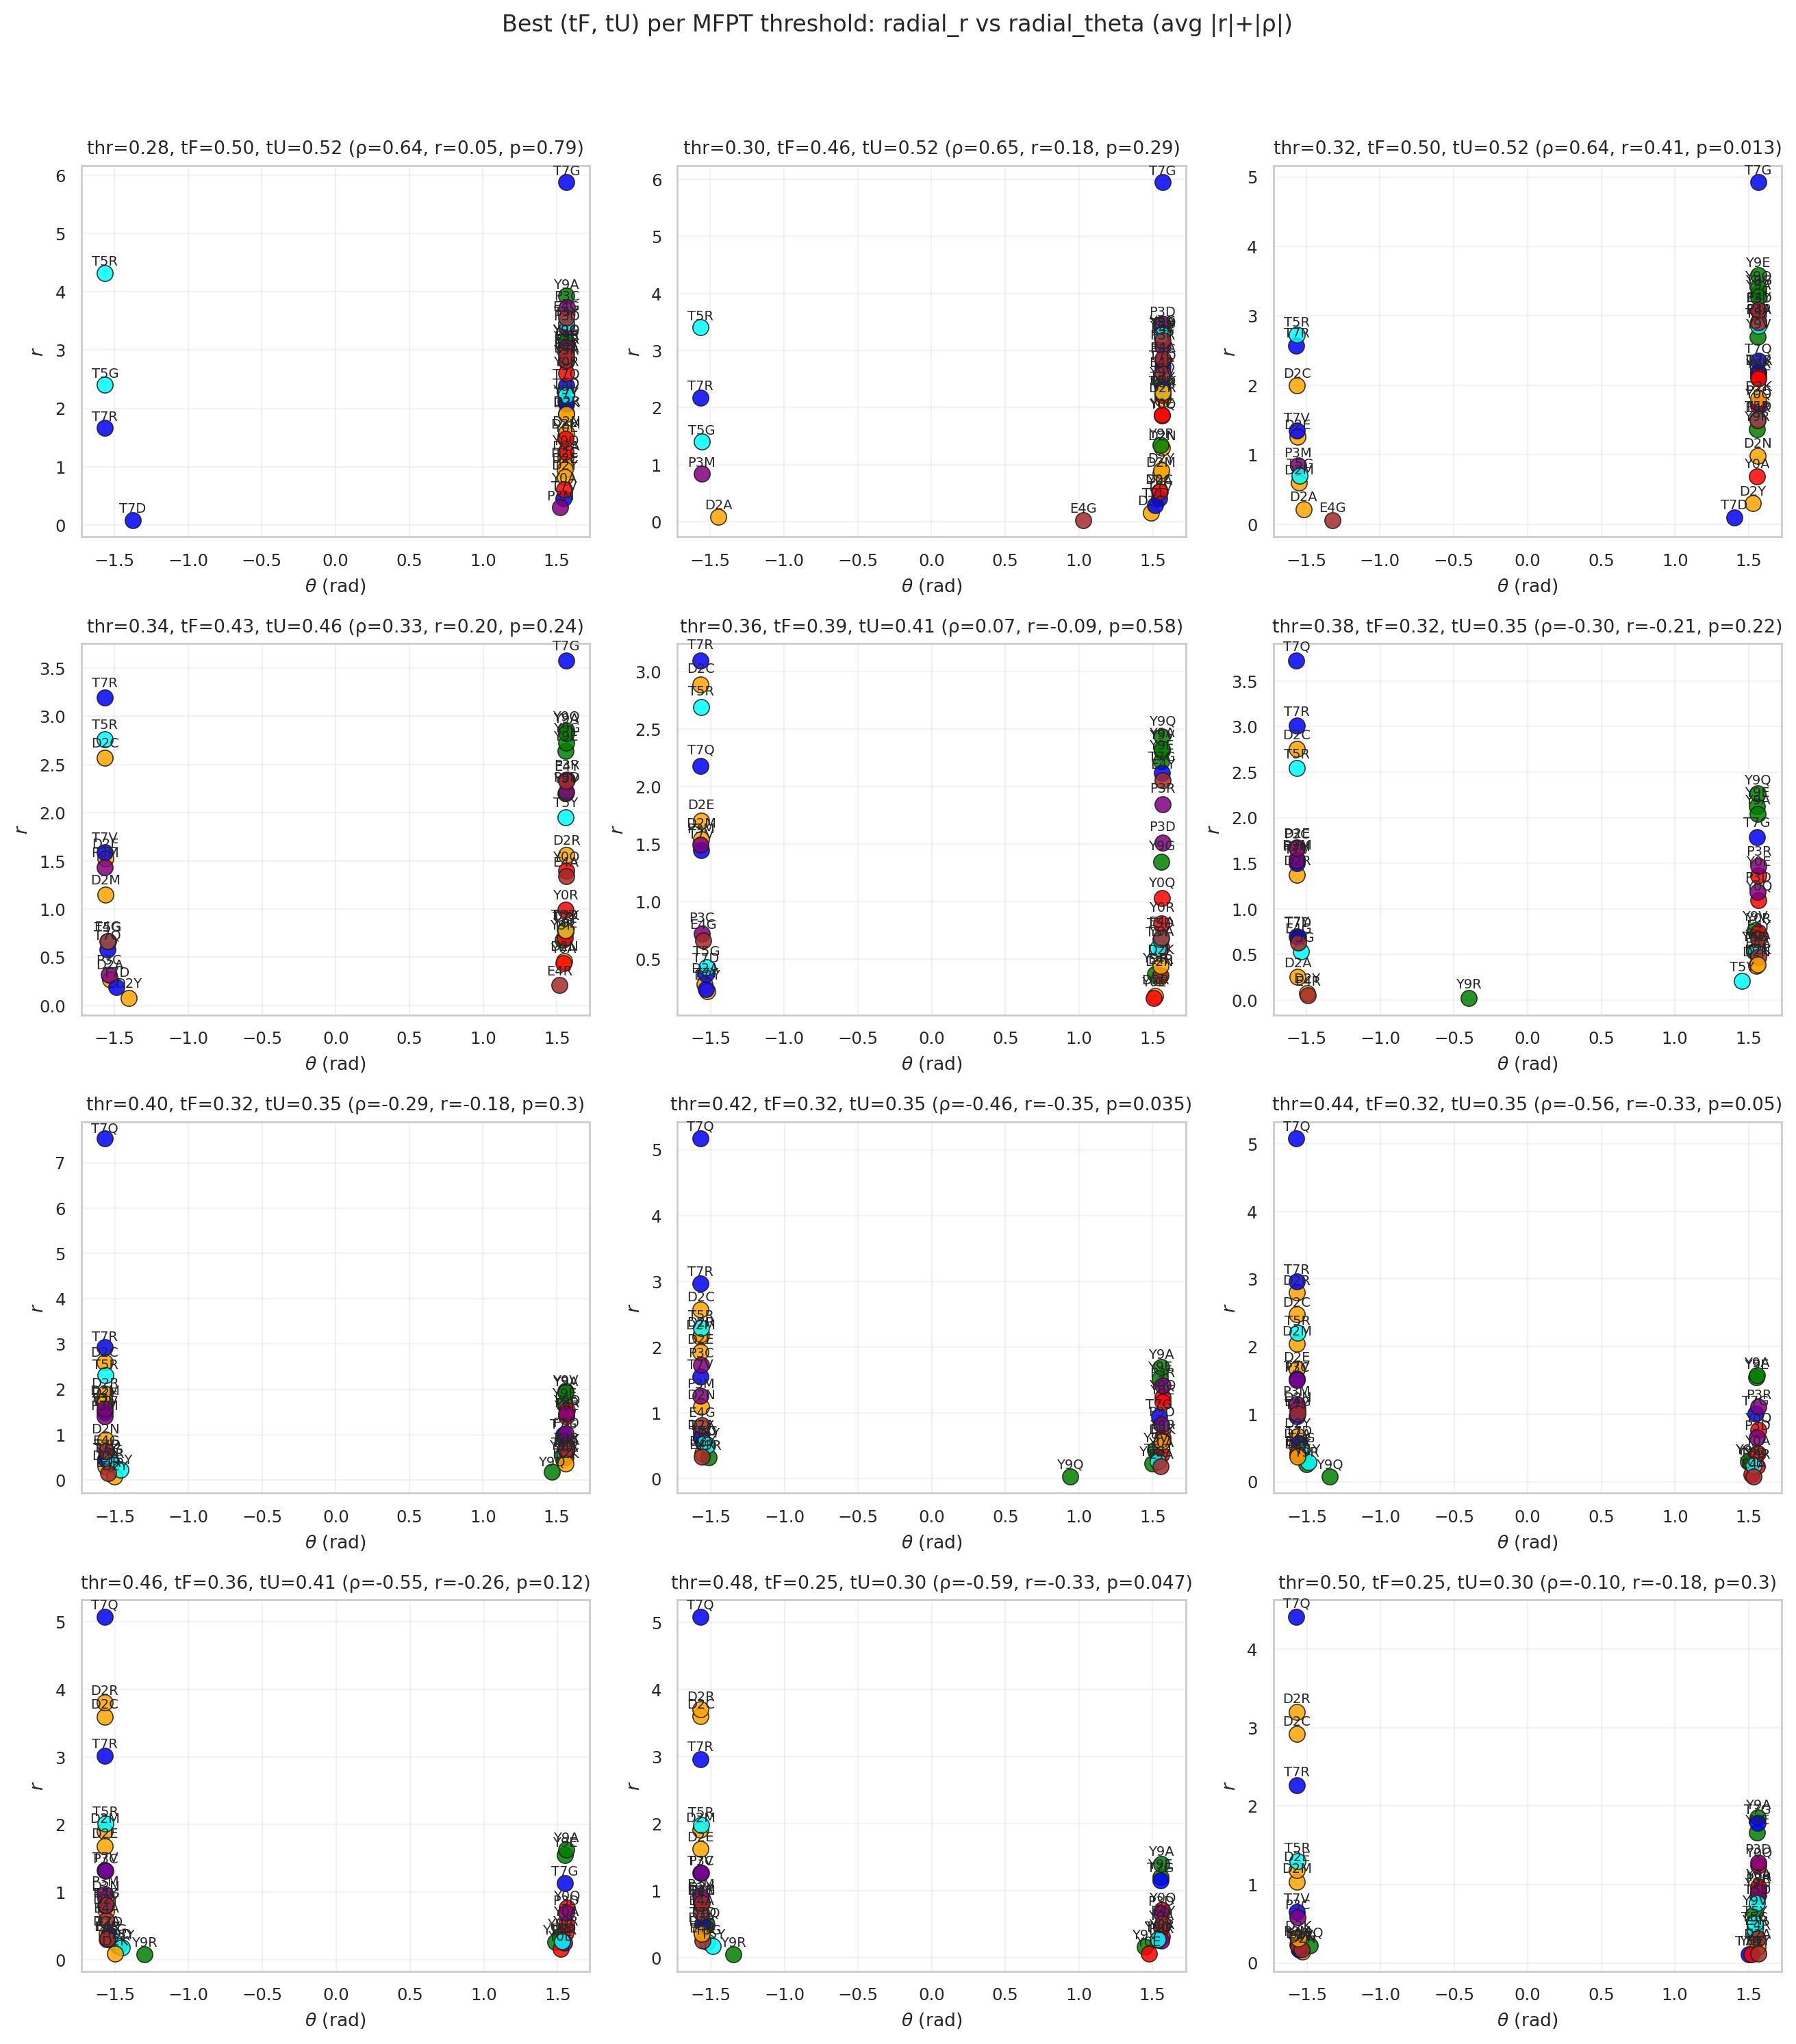

In [8]:
 #Best (tF, tU) per threshold for radial_r vs radial_theta
def best_rows_for_radial():
    best_rows = []
    for thr in mfpt_thresholds:
        rows = []
        for tF in unique_tf:
            for tU in unique_tu:
                df_thr = df_cache.get((float(thr), float(tF), float(tU)))
                if df_thr is None:
                    continue
                sub = df_thr.dropna(subset=['radial_r', 'radial_theta']).copy()
                if len(sub) < 2:
                    continue
                rho = sub['radial_r'].corr(sub['radial_theta'], method='spearman')
                pear, _ = pearsonr(sub['radial_r'], sub['radial_theta'])
                rows.append({
                    'tF': float(tF),
                    'tU': float(tU),
                    'rho': abs(rho) if pd.notna(rho) else np.nan,
                    'pear': abs(pear) if pd.notna(pear) else np.nan,
                })
        if not rows:
            continue
        df = pd.DataFrame(rows).dropna(subset=['rho', 'pear'])
        if df.empty:
            continue
        df['combo'] = 0.5 * (df['rho'] + df['pear'])
        best = df.loc[df['combo'].idxmax()]
        best_rows.append({
            'thr': float(thr),
            'tF': best['tF'],
            'tU': best['tU'],
            'rho': best['rho'],
            'pear': best['pear'],
            'combo': best['combo'],
        })
    return best_rows


def scatter_radial_r_theta(df, label, ax):
    sub = df.dropna(subset=['radial_r', 'radial_theta', 'residue_idx']).copy()
    if sub.empty:
        ax.axis('off')
        return

    sub['short'] = sub.index.astype(str)
    scatter_with_labels(
        ax,
        sub,
        'radial_theta',
        'radial_r',
        label_col='short',
        color_col='residue_idx',
        colors=res_colors,
    )

    rho = sub['radial_r'].corr(sub['radial_theta'], method='spearman')
    pear, p = pearsonr(sub['radial_r'], sub['radial_theta'])
    ax.set_title(f"{label} (ρ={rho:.2f}, r={pear:.2f}, p={p:.2g})")
    ax.set_xlabel(r"$\theta$ (rad)")
    ax.set_ylabel(r"$r$")
    ax.grid(True, alpha=0.25)


best_rows = best_rows_for_radial()

ncols = min(3, len(best_rows) if best_rows else 1)
nrows = int(np.ceil(len(best_rows) / ncols)) if best_rows else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)

for ax, b in zip(axes.ravel(), best_rows):
    tF = float(b['tF'])
    tU = float(b['tU'])
    thr = float(b['thr'])
    df_thr = df_cache.get((float(thr), float(tF), float(tU)))
    if df_thr is None:
        ax.axis('off')
        continue
    scatter_radial_r_theta(df_thr, f"thr={thr:.2f}, tF={tF:.2f}, tU={tU:.2f}", ax)

for ax in axes.ravel()[len(best_rows):]:
    ax.axis('off')

fig.suptitle("Best (tF, tU) per MFPT threshold: radial_r vs radial_theta (avg |r|+|ρ|)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()